In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/normal_bayes_newsvendor_50_50")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
with open(experiment_dir / "experiment.json", "r") as json_file:
    experiment = json.load(json_file)

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1

results_df

mean_cost    var_cost  \
uuid                                 replication                          
7d75335e-1c83-400b-a60c-9195bf343b97 0            38.023612  935.043801   
                                     1            33.410251  721.090273   
                                     2            37.567688  858.819768   
                                     3            34.545623  761.553244   
                                     4            34.579385  507.692581   
...                                                     ...         ...   
dfc9f8a5-7eb8-445a-a159-c936dbba442c 195          36.746508  560.481021   
                                     196          51.216561  472.504976   
                                     197          40.919186  669.968178   
                                     198          36.989849  363.481450   
                                     199          52.755911  593.146184   

                                                   solution  dgp_time  \
uuid                                 replication                        
7d75335e-1c83-400b-a60c-9195bf343b97 0            29.725281  0.000264   
                                     1            30.965558  0.000198   
                                     2            31.168187  0.000185   
                                     3            33.230021  0.000219   
                                     4            33.202297  0.000272   
...                                                     ...       ...   
dfc9f8a5-7eb8-445a-a159-c936dbba442c 195          22.461060  0.000615   
                                     196          27.272126  0.000677   
                                     197          26.806931  0.000617   
                                     198          22.891101  0.000624   
                                     199          31.033232  0.000617   

                                                  likelihood_time  \
uuid                                 replication                    
7d75335e-1c83-400b-a60c-9195bf343b97 0                   0.000073   
                                     1                   0.000067   
                                     2                   0.000067   
                                     3                   0.000071   
                                     4                   0.000104   
...                                                           ...   
dfc9f8a5-7eb8-445a-a159-c936dbba442c 195                 0.000065   
                                     196                 0.000071   
                                     197                 0.000072   
                                     198                 0.000064   
                                     199                 0.000067   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
7d75335e-1c83-400b-a60c-9195bf343b97 0                  0.001648    0.776809   
                                     1                  0.000080    0.778310   
                                     2                  0.000077    0.752227   
                                     3                  0.000082    0.773884   
                                     4                  0.000149    0.755389   
...                                                          ...         ...   
dfc9f8a5-7eb8-445a-a159-c936dbba442c 195                0.000062    0.614705   
                                     196                0.000073    0.611716   
                                     197                0.000064    0.614941   
                                     198                0.000064    0.596082   
                                     199                0.000062    0.593835   

                                                  setup_time    algorithm  \
uuid                                 replication                            
7d75335e-1c83-400b-a60c-9195bf3

In [3]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                  mean   
algorithm   dgp              epsilon inference posterior                 
our_kl_bdro normal           0.001   bayes     normal_gamma  37.866925   
                             0.002   bayes     normal_gamma  37.872884   
                             0.005   bayes     normal_gamma  37.886907   
                             0.010   bayes     normal_gamma  37.911852   
                             0.020   bayes     normal_gamma  37.960479   
                             0.050   bayes     normal_gamma  38.104545   
                             0.100   bayes     normal_gamma  38.350089   
                             0.150   bayes     normal_gamma  38.594686   
                             0.200   bayes     normal_gamma  38.834910   
                             0.250   bayes     normal_gamma  39.073705   
                             0.300   bayes     normal_gamma  39.312623   
                             0.400   bayes     normal_gamma  39.788208   
                             0.500   bayes     normal_gamma  40.260678   
                             1.000   bayes     normal_gamma  42.634829   
                             1.500   bayes     normal_gamma  44.977650   
                             2.000   bayes     normal_gamma  47.166784   
                             2.500   bayes     normal_gamma  49.011152   
                             3.000   bayes     normal_gamma  50.430049   
            truncated_normal 0.001   bayes     normal_gamma  32.390720   
                             0.002   bayes     normal_gamma  32.396481   
                             0.005   bayes     normal_gamma  32.411010   
                             0.010   bayes     normal_gamma  32.435284   
                             0.020   bayes     normal_gamma  32.480984   
                             0.050   bayes     normal_gamma  32.615890   
                             0.100   bayes     normal_gamma  32.823862   
                             0.150   bayes     normal_gamma  33.020658   
                             0.200   bayes     normal_gamma  33.214971   
                             0.250   bayes     normal_gamma  33.404462   
                             0.300   bayes     normal_gamma  33.588879   
                             0.400   bayes     normal_gamma  33.952696   
                             0.500   bayes     normal_gamma  34.311887   
                             1.000   bayes     normal_gamma  36.048140   
                             1.500   bayes     normal_gamma  37.719574   
                             2.000   bayes     normal_gamma  39.272530   
                             2.500   bayes     normal_gamma  40.577317   
                             3.000   bayes     normal_gamma  41.577302   

                                                                        \
                                                                   var   
algorithm   dgp              epsilon inference posterior                 
our_kl_bdro normal           0.001   bayes     normal_gamma  20.743553   
                             0.002   bayes     normal_gamma  20.759692   
                             0.005   bayes     normal_gamma  20.775157   
                             0.010   bayes     normal_gamma  20.812169   
                             0.020   bayes     normal_gamma  20.919801   
                             0.050   bayes     normal_gamma  21.242108   
                             0.100   bayes     normal_gamma  21.976413   
                             0.150   bayes     normal_gamma  22.763159   
                             0.200   bayes     normal_gamma  23.554010   
                             0.250   bayes     normal_gamma  24.418142   
                             0.300   bayes     normal_gamma  25.274987   
                             0.400   bayes     normal_gamma  27.046352   
                             0.500   bayes     normal_gamma  28.

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

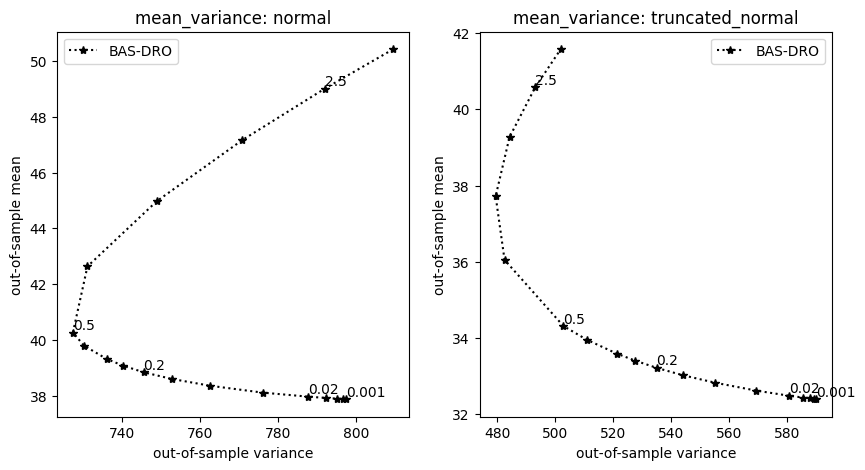

In [4]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
fig.show()

## Solve time

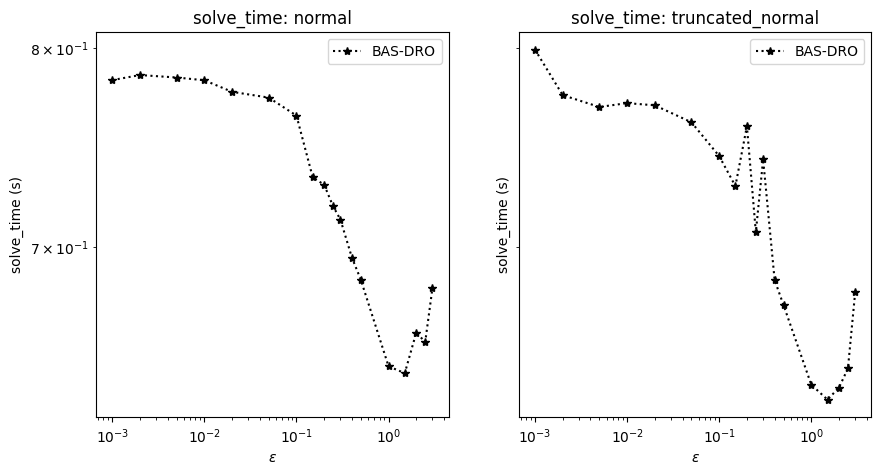

In [5]:
fig, axes = flexible_figure(agg_df, "solve_time", compare_col="algorithm", gb_col="dgp", sharex=True, sharey=True, ncols=2)
fig.show()

In [6]:
# what is the constant G?
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_kl_bdro_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_kl_bdro_constant("normal_gamma", theta_posterior)

dgp = "normal"
posterior = "normal_gamma"
num_observations = 10
G_constant = []
posterior_expected_kl = []
prior_expected_kl = []
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_kl_bdro_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.mean(G_constant), np.var(G_constant)

(0.08827544585267265, 1.925929944387236e-34)

In [7]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.16462497724528255, 0.012848186395172448)

In [8]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.78569035285864, 0.0)

In [9]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 794.3194647834051, 17.727414116711756)

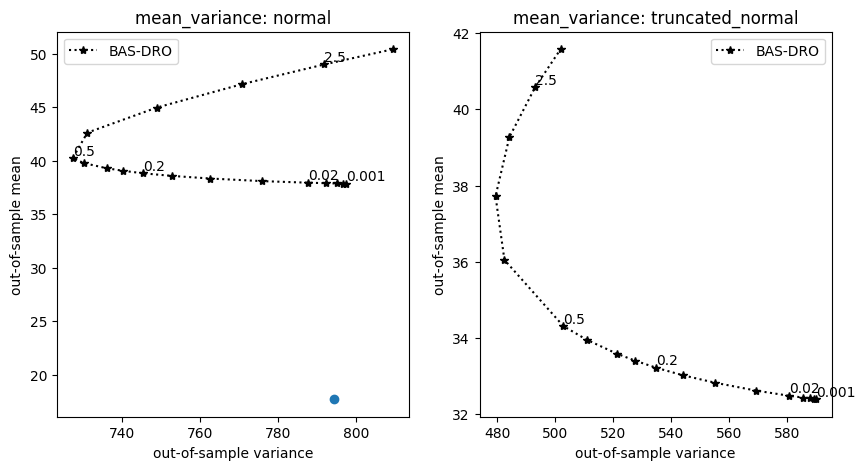

In [10]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
axes[0].scatter(mean_of_variances, var_of_means)
fig.show()

epsilon | mean squared error to opt | std of mean squared error
----------
0.1 | 